In [1]:
import os
import pandas as pd
import glob
import sys

In [2]:
car_bike_dataset = r"/home/Senthilkumar/project_files/Image_classification/All_datasets/Car-Bike-Dataset"

In [3]:
image_labels = {}
for filepath in glob.glob(os.path.join(car_bike_dataset,"**","*.jpeg"), recursive=True):
    # category = os.path.basename(os.path.dirname(filepath))
    image_labels[filepath] = os.path.basename(os.path.dirname(filepath))
car_bike_df = pd.DataFrame(image_labels.items(), columns = ['filepath', 'label'])
car_bike_df.head()

,filepath,label
0,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
1,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
2,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
3,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
4,/home/meduser@quest-global.com/Senthilkumar/pr...,Car


In [76]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.style.available


['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [81]:
plt.style.use("seaborn-v0_8")

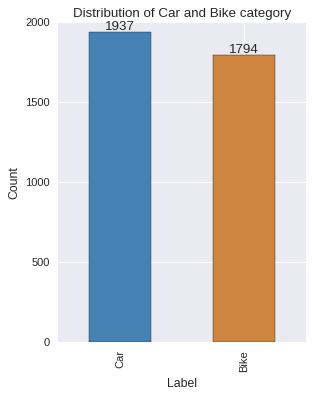

In [82]:
fig, axs = plt.subplots(figsize=(4,5))
color=['steelblue', 'peru']
ax = car_bike_df['label'].value_counts().plot.bar(color=color, xlabel="Label", ylabel="Count", title="Distribution of Car and Bike category")
for container in ax.containers:
    ax.bar_label(container)

In [5]:
# splitting into train, validation and test set

In [6]:
from sklearn.model_selection import train_test_split
x, y = car_bike_df['filepath'], car_bike_df['label']
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.15, random_state=42, stratify=y)
print(x_train)
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size = 0.10, random_state=42, stratify=y_train)
print(x_test, y_test)

1134    /home/meduser@quest-global.com/Senthilkumar/pr...
1725    /home/meduser@quest-global.com/Senthilkumar/pr...
2184    /home/meduser@quest-global.com/Senthilkumar/pr...
1347    /home/meduser@quest-global.com/Senthilkumar/pr...
2374    /home/meduser@quest-global.com/Senthilkumar/pr...
                              ...                        
945     /home/meduser@quest-global.com/Senthilkumar/pr...
1487    /home/meduser@quest-global.com/Senthilkumar/pr...
1536    /home/meduser@quest-global.com/Senthilkumar/pr...
3485    /home/meduser@quest-global.com/Senthilkumar/pr...
3523    /home/meduser@quest-global.com/Senthilkumar/pr...
Name: filepath, Length: 3171, dtype: object
26      /home/meduser@quest-global.com/Senthilkumar/pr...
298     /home/meduser@quest-global.com/Senthilkumar/pr...
3102    /home/meduser@quest-global.com/Senthilkumar/pr...
2030    /home/meduser@quest-global.com/Senthilkumar/pr...
3222    /home/meduser@quest-global.com/Senthilkumar/pr...
                            

In [83]:
car_bike_train = pd.DataFrame(columns = ['filepath', 'label'])
car_bike_train['filepath'] = x_train
car_bike_train['label'] = y_train
car_bike_train.reset_index(drop=True, inplace=True)

car_bike_val = pd.DataFrame(columns = ['filepath', 'label'])
car_bike_val['filepath'] = x_val
car_bike_val['label'] = y_val
car_bike_val.reset_index(drop=True, inplace=True)

car_bike_test = pd.DataFrame(columns = ['filepath', 'label'])
car_bike_test['filepath'] = x_test
car_bike_test['label'] = y_test
car_bike_test.reset_index(drop=True, inplace=True)

In [84]:
car_bike_train.head()

,filepath,label
0,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
1,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
2,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
3,/home/meduser@quest-global.com/Senthilkumar/pr...,Car
4,/home/meduser@quest-global.com/Senthilkumar/pr...,Car


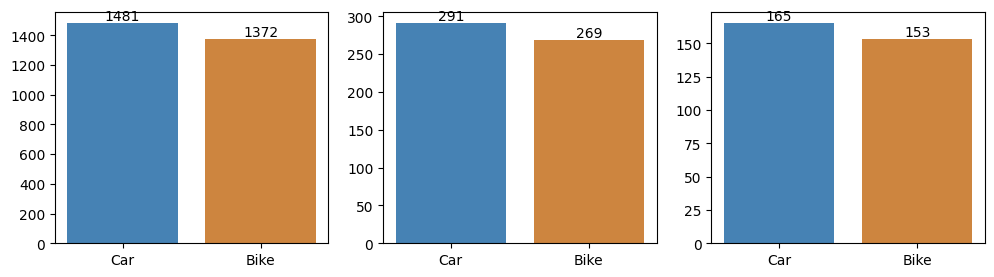

In [9]:

fig, axs = plt.subplots(1,3, figsize = (12,3))
colors=['steelblue', 'peru']
train_count, val_count, test_count = car_bike_train['label'].value_counts(), car_bike_val['label'].value_counts(), car_bike_test['label'].value_counts()
for ax, count in zip(axs, [train_count, val_count, test_count]):
    container = ax.bar(count.index, count.values, color=colors,)
    ax.bar_label(container, count.values)


In [10]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SubsetRandomSampler, random_split
from torchvision import transforms, models
# from torchvision.io import read_image
from PIL import Image
import cv2

In [11]:
class CarBikeDataset(Dataset):
    def __init__(self, dataframe, feature_transform=None, target_transform=None):
        self.filepath = dataframe['filepath']
        self.label = dataframe['label']
        self.feature_transform = feature_transform
        self.target_transform = target_transform

    
    def __getitem__(self, idx):
        img = Image.open(self.filepath[idx])
        # img = cv2.imread(self.filepath[idx])
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # print(type(img))
        label = self.label[idx]
        category = sorted(self.label.unique())
        
        if self.feature_transform :
            img = self.feature_transform(img)
        if self.target_transform:
            label = self.target_transform(label, category)
        return img, label
        
        
    def __len__(self):
        return len(self.filepath)
    

In [12]:
def binary_encoding(label, category):
    """
    Encodes for Binary Classification
    label : string
    category : sorted list of labels
    """
    encoded_label = torch.FloatTensor([category.index(label)])
    return encoded_label

def nonbinary_encoding(label, category):
    """
    Encodes for Multi Class Classification
    label : string
    category : sorted list of labels
    One hot encoding ex.: label='category1', categories=['category0', 'category1', 'category2'], return=[0, 1, 0].
    """
    encoded_label = torch.zeros(len(category))
    index = category.index(label)
    encoded_label[index]=1
    return encoded_label

def make_balanced_sampler(y):
    """
    Generates weighted sampler based on the distribution of target label
    y : Pandas series or Tensor
    Generally used for imbalanced dataset
    """
    import pandas
    import torch
    torch.set_printoptions(precision=5)
    if isinstance(y, pandas.core.series.Series):
        y = (y.apply(lambda x: binary_encoding(x, sorted(y.unique())))).astype(float)
        y = torch.tensor(y)
        classes, counts = y.unique(return_counts=True)
    elif isinstance(y, torch.Tensor):
        classes, counts = y.unique(return_counts=True)
    else:
        print("Something wrong happend")
    weights = 1.0 / counts.float()
    sample_weights = weights[y.squeeze().long()]
    print(y[:10])
    print(sample_weights[:10])
    # Builds sampler with compute weights
    generator = torch.Generator()
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        generator=generator,
        replacement=True
    )
    return sampler

In [13]:
train_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                                      transforms.ToTensor()
                                    ])
valid_transform = transforms.Compose([transforms.Resize(256),
                                      transforms.CenterCrop(224),
                                      # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                                      transforms.ToTensor()
                                     
                                     ])
test_transform = transforms.Compose([transforms.Resize(256),
                                    transforms.CenterCrop(224),
                                     # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                                     transforms.ToTensor(),
                                      
                                     ])

In [14]:
train_dataset = CarBikeDataset(car_bike_train, feature_transform=train_transform, target_transform=binary_encoding)
val_dataset = CarBikeDataset(car_bike_val, feature_transform=valid_transform, target_transform=binary_encoding)
test_dataset = CarBikeDataset(car_bike_test, feature_transform=test_transform, target_transform=binary_encoding)


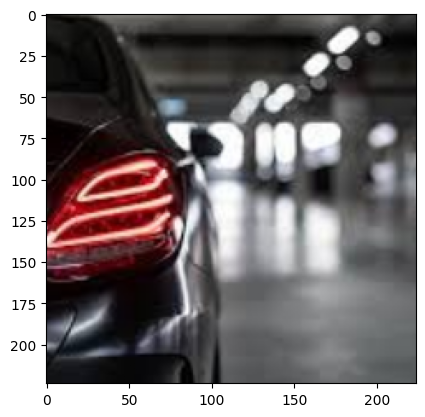

In [15]:
temp_image = val_dataset[0][0].numpy()
temp_image = temp_image.transpose((1,2,0))

plt.imshow(temp_image)

In [16]:
val_dataset[0][0].numpy()

array([[[0.14901961, 0.16078432, 0.18039216, ..., 0.23137255,
         0.23137255, 0.23137255],
        [0.05882353, 0.06666667, 0.07450981, ..., 0.24705882,
         0.24313726, 0.21568628],
        [0.08235294, 0.07450981, 0.07058824, ..., 0.23529412,
         0.22352941, 0.20784314],
        ...,
        [0.06666667, 0.06666667, 0.06666667, ..., 0.34509805,
         0.3372549 , 0.34117648],
        [0.06666667, 0.06666667, 0.06666667, ..., 0.34901962,
         0.34117648, 0.34509805],
        [0.07058824, 0.07058824, 0.07058824, ..., 0.3529412 ,
         0.34509805, 0.34901962]],

       [[0.14509805, 0.15686275, 0.1764706 , ..., 0.23137255,
         0.23137255, 0.23137255],
        [0.05490196, 0.0627451 , 0.07058824, ..., 0.24705882,
         0.24313726, 0.21568628],
        [0.07843138, 0.07058824, 0.06666667, ..., 0.23529412,
         0.22352941, 0.20784314],
        ...,
        [0.07058824, 0.07058824, 0.07058824, ..., 0.36078432,
         0.3529412 , 0.35686275],
        [0.0

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, sampler=make_balanced_sampler(car_bike_train['label']))
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0.], dtype=torch.float64)
tensor([0.00068, 0.00068, 0.00068, 0.00068, 0.00068, 0.00068, 0.00073, 0.00068,
        0.00068, 0.00073])


In [18]:
img, labl = next(iter(val_loader))
img.shape

torch.Size([32, 3, 224, 224])

In [19]:
for img, labels in val_loader:
    print(img.shape)
    print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([32, 3, 224, 224])
torch.Size([32, 1])
torch.Size([16, 3, 224, 224])
torch.Size([16, 1])


In [20]:
from StepbyStep import StepByStep
from Classification_Models import classification_model
from torch import optim
vgg16_model, resnet50_model, mobilenet_model = classification_model(1)

/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to g

classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias
classifier.6.weight
classifier.6.bias


In [21]:
for param in vgg16_model.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True
True
True


In [22]:
model = vgg16_model

loss_fn = nn.BCEWithLogitsLoss(reduction='mean')
# multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
new_optimizer = optim.Adam(model.parameters(), lr=3e-4)

sbs_cnn2 = StepByStep(model, loss_fn, new_optimizer)
sbs_cnn2.set_loaders(train_loader, val_loader)
sbs_cnn2.train(10)

1/10, train_loss = 0.21849246778421932, val_loss=0.057904576268305794
2/10, train_loss = 0.16475077655632048, val_loss=0.13838847723996472
3/10, train_loss = 0.13678628072763482, val_loss=0.0640045105978465
4/10, train_loss = 0.13250052012606628, val_loss=0.03281925631664409
5/10, train_loss = 0.12158937792668843, val_loss=0.05162440381375038
6/10, train_loss = 0.13238086491409276, val_loss=0.034084051262147516
7/10, train_loss = 0.11456786823699884, val_loss=0.0418780699352889
8/10, train_loss = 0.11409604793621433, val_loss=0.06558414062763201
9/10, train_loss = 0.0886546387447096, val_loss=0.05530737174558453
10/10, train_loss = 0.10600033530241085, val_loss=0.03868071085566448


In [35]:
result = sbs_cnn2.loader_apply(test_loader, sbs_cnn2.correct)
result

In [59]:
result[:,0]/result[:, 1]

tensor([0.95425, 0.99394])

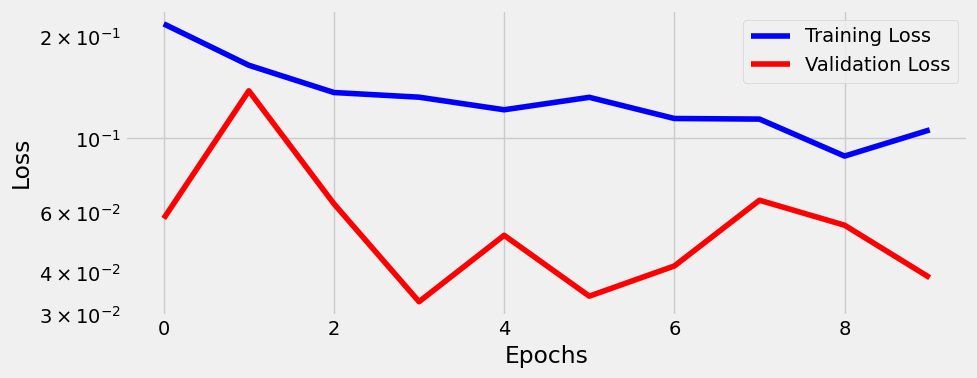

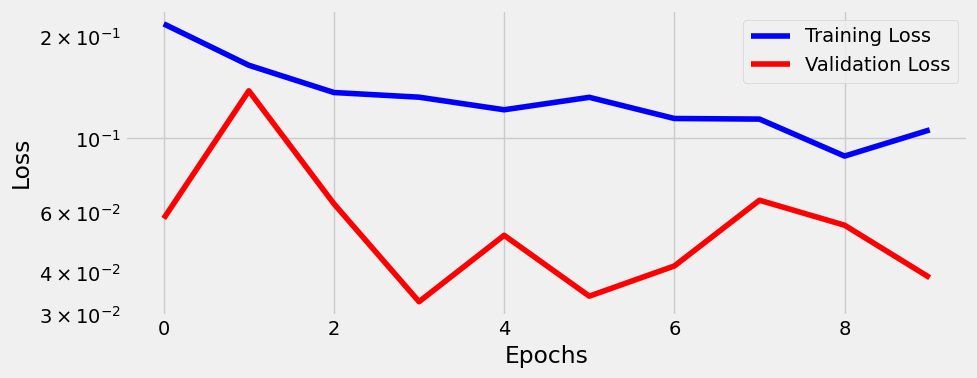

In [62]:
sbs_cnn2.plot_losses()

In [63]:
sbs_cnn2.save_checkpoint("car_bike_classifier")

In [65]:
sbs_cnn2.count_parameters()

119549953

In [85]:
torch.cuda.empty_cache()